# My Silver Medal Solution - Sliding Time Cross Validation - for Kaggle's ICR Comp
Here was my third choice final solution for Kaggle's ICR competition. In this competition, I had 3 final subs:
* Time-CV Model with no funny business (i.e. this notebook with more discussion [here][1])
* LB Probing Pseudo Label model 😀 (probing explained [here][2] and [here][4]. And shown [here][3])
* LB Probing Pseudo Label with conservative PP Threshold model 😀 (threshold analysis shown in this notebook)

For my final two submission, I picked the two risky ones (i.e. last 2 bullet points) because I was trying to win a top position. If my goal was to just obtain a medal, I would have chosen the first two bullet points because the first bullet point uses basic data science and should do well. 

I thought the last two bullet points would work but they did not. Using probed ground truth from public LB as extra train data hurt the private LB score by `-0.02`. And using a very conservative threshold PP of `pred[pred<0.1]=0` hurt the private LB by `-0.40`. (More discussion about my final solution [here][1])

[1]: https://www.kaggle.com/competitions/icr-identify-age-related-conditions/discussion/431067
[2]: https://www.kaggle.com/competitions/icr-identify-age-related-conditions/discussion/430764#2386580
[3]: https://www.kaggle.com/code/cdeotte/use-public-lb-probing-data-lb-0-0
[4]: https://www.kaggle.com/competitions/icr-identify-age-related-conditions/discussion/431275

# Why Use Time Cross Validation?
Normally i would not think that time matters in a medical diagnosis competition. However if you add time as a feature it becomes the most important XGB feature. This implies that target and features are changing (i.e. dependent) on time. (More information [here][1])

We want our model to do well on the private test data which the host says is in the future. This means it will have a different feature and target distribution. We want to build a model which can train on one time period and infer well on another time period. Hence we use sliding window time CV.

Using sliding window time CV we can test each model to see what works best. For example SVC, Logistic Regression, XGB, TabPFN, etc etc. Doing so, I found that an equal blend of TabPFN, XGB, and LGBM did best. Furthermore the CV found optimal hyperparameters. Noteably these hyperparameters are different than public notebooks and do better on test data. For example, we can use a `for-loop` and run our Time-CV multiple iterations to evaluate different `number of iterations` for XGBoost and LGBM. Below is a plot showing the results of this experiment. The optimal number of iterations are 125 for LGBM and 100 for XGB. Similarily we use time-CV to find all other GBT parameters.

![](https://raw.githubusercontent.com/cdeotte/Kaggle_Images/main/Aug-2023/time-cv-eda.png)

Also using time CV, we can perform recursive feature elimination. I executed a for-loop and discovered 8 features that hurt the CV score. This means that these 8 features do not predict well in time. Their distribution and/or correlation with the target is unstable. Removing these 8 features improve CV score (by about +0.02) and improve public LB (slightly). Unfortunately they hurt private LB (by -0.03). If i submit this notebook without removing features (i.e. `DROP_SOME_FEATURES = False`) it achieves private LB `0.35` gold medal. Since the train data is so small, I'm still unsure how to successfully remove features in a robust way.

[1]: https://www.kaggle.com/competitions/icr-identify-age-related-conditions/discussion/431519

# Install TabPFN

In [ ]:
!pip install tabpfn --no-index --find-links=file:///kaggle/input/pip-packages-icr/pip-packages
!mkdir -p /opt/conda/lib/python3.10/site-packages/tabpfn/models_diff
!cp /kaggle/input/pip-packages-icr/pip-packages/prior_diff_real_checkpoint_n_0_epoch_100.cpkt /opt/conda/lib/python3.10/site-packages/tabpfn/models_diff/

# Load Test Data
We will load test data and define our sliding validation size

In [ ]:
# USE TRAIN DATA WITHOUT DATES?
USE_ALL = True
DROP_SOME_FEATURES = True

# EACH VALIDATION WILL BE SIZE OF 5-FOLD
# WE WILL SLIDE THIS WINDOW 25 TIMES
LIKE_FOLD = 5
NUM_FOLDS = 25

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

test = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/test.csv')
# BN is age, let's convert to integers
test.BN = (test.BN/0.3531).astype('int32')
# EJ is redundant, let's remove
test = test.drop('EJ',axis=1)
print('Test data shape:', test.shape )
test.head()

# Load Train Data
Using recursive feature elimination, we found the following 8 features to drop `['AZ','BP','BZ','CF','DH','EU','FR','GB']`. Recursive feature elimination is using a for-loop and each iteration we try dropping a feature one by one. Then we add the one feature whose removal boosted CV score the most to removal list. Next iteration, we keep the worst feature removed and then try dropping each feature again. Afterward we add the one new feature whose removal boosted CV the most to the list. Now we have 2 removal features. We repeat this process until removing features does not help.

Note that removing these 8 features boost both CV and public LB. However removing these features hurt private LB by `-0.02`. If we do not remove features, then our private LB score is `+0.02` better and enters the Gold range of `0.30 thru 0.37`.

In [ ]:
train = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/train.csv')
# BN is age, let's convert to integers
train.BN = (train.BN/0.3531).astype('int32')
# EJ is redundant, let's remove
train = train.drop('EJ',axis=1)

RMV = ['AZ','BP','BZ','CF','DH','EU','FR','GB']
if not DROP_SOME_FEATURES: RMV = []
FEATURES = [f for f in list( train.columns[1:-1] ) if not f in RMV]

print('We will drop',len(RMV),'features')
print('We will use', len(FEATURES) ,'features.')
print('Full Train data shape:', train.shape )
display( train.head() )

greeks = pd.read_csv('/kaggle/input/icr-identify-age-related-conditions/greeks.csv')
print('Greeks shape:', greeks.shape )
greeks.head()

# Merge Date Column to Train
We merge date column so we can use it for our time cv. There is not much data before 2017, so we will remove this data.

In [ ]:
train = train.merge(greeks,on='Id',how='left')
train.loc[train.Epsilon=='Unknown','Epsilon'] = np.nan
train['dt'] = pd.to_datetime(train.Epsilon)
print('Oldest train data is',train['dt'].min())

In [ ]:
train['days'] = (train['dt'] - train['dt'].min()).dt.days
train['year'] = train['dt'].dt.year
train = train.loc[(train.year>=2017)|train.days.isna()]
train['days'] -= train.days.min()

In [ ]:
print('We have',train.days.max()+1,'unique days in our train data')

# Add Data Without Date
If our config parameter named `USE_ALL` is set to false, then we will remove train data without a date. Otherwise we will assign a random date to all train data without a date.

In [ ]:
print('Train data shape before', train.shape )
if not USE_ALL:
    train = train.loc[train.days.notnull() & (train.year>=2017)].sort_values('days').reset_index(drop=True)
else:
    np.random.seed(42)
    train.loc[train.days.isna(),'days'] = np.random.randint(0,train.days.max(),train.days.isna().sum())
    train = train.sort_values('days').reset_index(drop=True)
    np.random.seed(None)
print('Train data shape after', train.shape)

# Sliding Time Cross Validation
The train data is sorted by date. We then train 25 fold models and compute 25 validation scores. We slide from left to right which data we will use for validation. All other data is used for training. Each fold model then infers the test data for our submission.

In [ ]:
print(f'Validation Folds are same size as {LIKE_FOLD}-Fold CV')
LB = len(train)//LIKE_FOLD
CT = len(train) - LB
STEP = CT // (NUM_FOLDS - 1)
print('One fold train size =',CT)
print('One fold validation size =', LB )
FF = NUM_FOLDS
print('We slide our validation window',FF,'times')
extra_data = len(train) - ((FF-1)*STEP + LB)

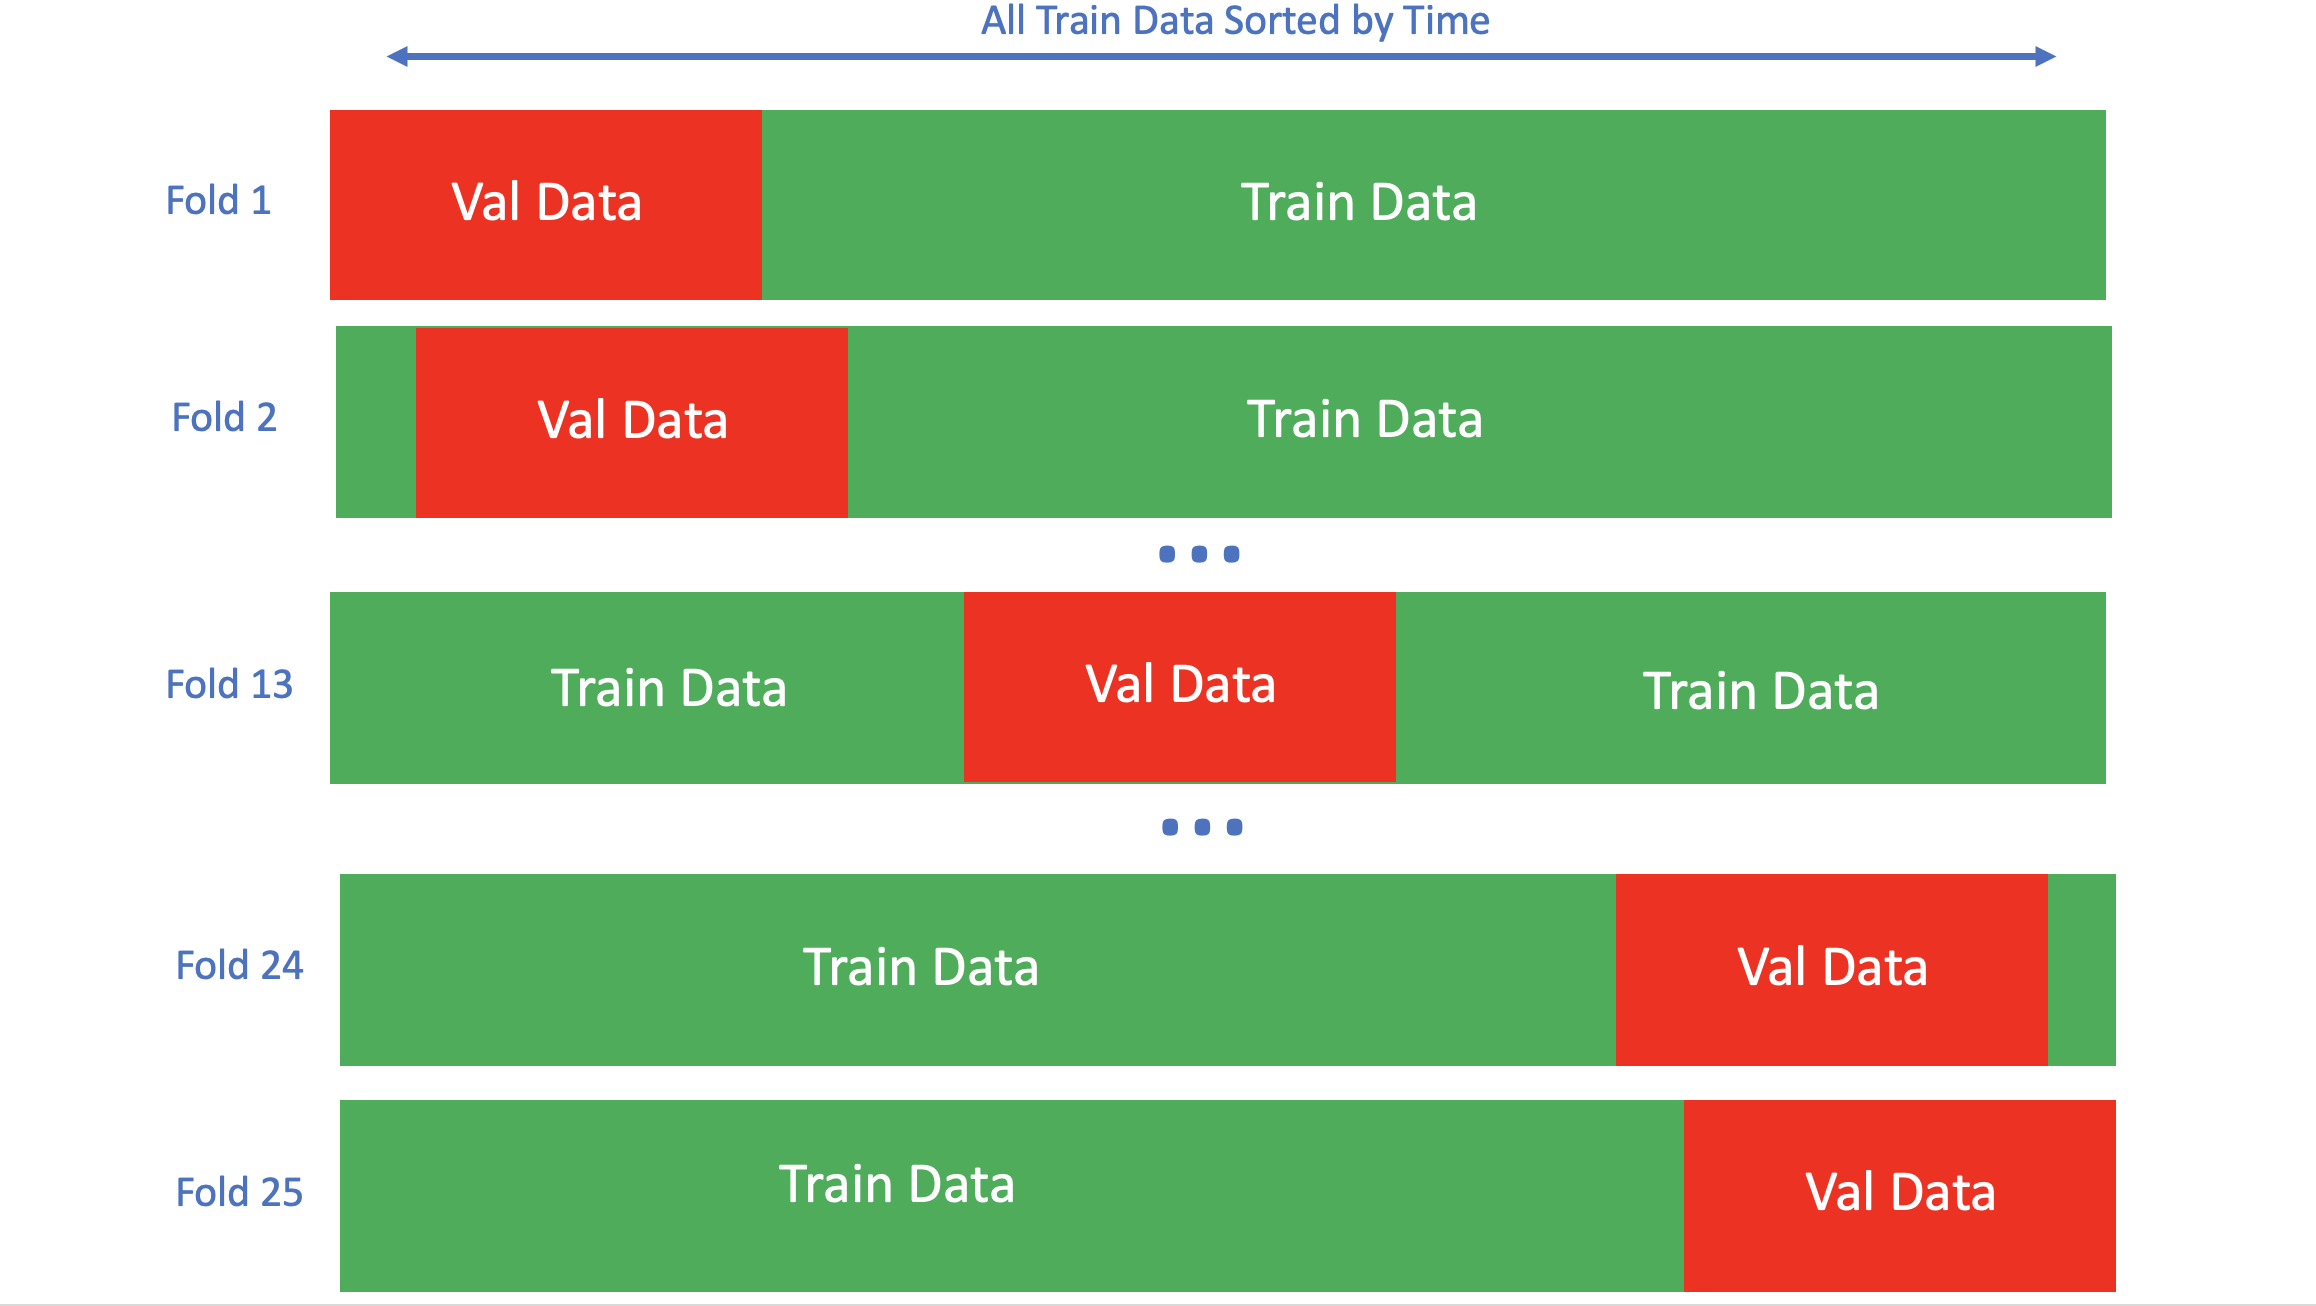

# Models TabPFN, XGBoost, LGBM

In [ ]:
# LOAD XGB LIBRARY
from sklearn.model_selection import KFold, GroupKFold
from sklearn.metrics import roc_auc_score, log_loss

import xgboost as xgb
print('XGB Version',xgb.__version__)

from tabpfn import TabPFNClassifier

import lightgbm as lgb
print('LGB Version',lgb.__version__)

In [ ]:
# XGB MODEL PARAMETERS
SEED = 42
xgb_parms = {
                'max_depth' : 5,
                'learning_rate' : 0.1,
                'subsample' : 0.9,
                'colsample_bytree' : 0.4,
                'colsample_bylevel' : 0.4,
                #'tree_method' : 'gpu_hist',
                'tree_method' : 'hist',
                'objective':'binary:logistic',
                'eval_metric':'logloss',
            }

# WEIGHTS NEED TO COMPUTE BALANCED LOGLOSS METRIC
c0 = (train.Class==0).sum()
c1 = (train.Class==1).sum()
W0 = 1/c0 ; W1 = 1/c1 
MP = {0:W0,1:W1}
train['wgt'] = train.Class.map(MP)

In [ ]:
%%time

all_preds = []

oof = np.zeros(len(train))
importances = []
importances2 = []
ms = []
ds = []

tops = []
bottoms = []
all_oofs = []
all_trues = []
all_wgts = []

for fold in range(FF):
    
    a = fold * STEP + min(fold,extra_data)
    b = fold * STEP + LB + min(fold+1,extra_data)
    valid_idx = np.arange(a,b)
    train_idx = np.setdiff1d(np.arange(len(train)),valid_idx)
    ds.append( train.loc[valid_idx,'days'].max() )
    ct = train.loc[valid_idx,'Class'].sum()

    print('#'*25)
    print('### Fold',fold+1)
    print('### Train size',len(train_idx),'Valid size',len(valid_idx),f'with {ct} pos')
    print('#'*25)

    # TRAIN, VALID, TEST
    X_train = train.loc[train_idx,FEATURES]
    y_train = train.loc[train_idx,'Class']
        
    X_valid = train.loc[valid_idx,FEATURES]
    y_valid = train.loc[valid_idx,'Class']
    
    X_test = test[FEATURES]
    
    # LGBM
    model3 = lgb.LGBMClassifier(boosting_type='goss', 
                        learning_rate= 0.1,  
                        n_estimators = 125,  
                        random_state=42,
                        #subsample=0.9,
                        #colsample_bytree=0.9,
                        class_weight='balanced',
                        n_jobs=4,
                        metric='none', is_unbalance=True, max_depth=7)
    model3.fit(X_train, y_train)
    
    # XGB
    dtrain = xgb.DMatrix(X_train,y_train)
    dvalid = xgb.DMatrix(X_valid,y_valid)
    dtest = xgb.DMatrix(X_test)
    model2 = xgb.train(xgb_parms, 
                dtrain=dtrain,
                evals=[(dtrain,'train'),(dvalid,'valid')],
                num_boost_round=100,
                verbose_eval=0)

    # TABPFN
    model = TabPFNClassifier(N_ensemble_configurations=8)
    model.fit(X_train, y_train, overwrite_warning = True)

    # OOF PREDS
    oof_preds = model.predict_proba(X_valid)[:,1]
    oof_preds2 = model2.predict(dvalid)
    oof_preds3 = model3.predict_proba(X_valid)[:,1]
    oof_preds = 0.34*oof_preds + 0.33*oof_preds2 + 0.33*oof_preds3
    oof_preds = np.stack([1-oof_preds,oof_preds]).T
    class_0_est_instances = oof_preds[:,0].sum() 
    others_est_instances = oof_preds[:,1].sum() 
    new_probabilities = oof_preds * np.array([[1/(class_0_est_instances if i==0 else others_est_instances) 
                                               for i in range(oof_preds.shape[1])]])
    new_probabilities = new_probabilities / np.sum(new_probabilities, axis=1, keepdims=1) 
    oof[valid_idx] = new_probabilities[:,1]
    
    # TEST PREDS
    oof_preds = model.predict_proba(X_test)[:,1]
    oof_preds2 = model2.predict(dtest)
    oof_preds3 = model3.predict_proba(X_test)[:,1]
    oof_preds = 0.34*oof_preds + 0.33*oof_preds2 + 0.33*oof_preds3
    oof_preds = np.stack([1-oof_preds,oof_preds]).T
    class_0_est_instances = oof_preds[:,0].sum() 
    others_est_instances = oof_preds[:,1].sum() 
    new_probabilities = oof_preds * np.array([[1/(class_0_est_instances if i==0 else others_est_instances) 
                                               for i in range(oof_preds.shape[1])]])
    new_probabilities = new_probabilities / np.sum(new_probabilities, axis=1, keepdims=1) 
    all_preds.append( new_probabilities[:,1] )

    # COMPUTE OOF SCORE
    m = log_loss(y_valid, oof[valid_idx], 
         sample_weight=train.wgt.values[valid_idx], eps=1e-15)
    print('=> Balanced Log Loss =',m)
    ms.append(m)
    
    mn = np.min( oof[valid_idx][y_valid==1] )
    bottoms.append(mn)
    mx = np.max( oof[valid_idx][y_valid==0] )
    tops.append(mx)
    
    all_oofs.append( oof[valid_idx] )
    all_trues.append( y_valid )
    all_wgts.append( train.wgt.values[valid_idx] )

# Save Submission CSV

In [ ]:
# SAVE SUBMISSION CSV TO DISK
print( len(all_preds) )
preds = np.mean( all_preds,axis=0 )
sub = test[['Id']].copy()
sub['class_0'] = 1-preds
sub['class_1'] = preds
sub.to_csv('submission.csv', index=False)
print('Final submission shape:', sub.shape )
sub.head()

# CV Analysis
We will now compute the best fold balanced log loss, worse fold, and mean overall balanced log loss. Also we will plot the 25 folds with x axis date (equal to the largest date in each validation fold).

In [ ]:
best = np.argmin(ms)
print('Best balanced log-loss =', np.min( ms ), 'at fold', best+1 )

worst = np.argmax(ms)
print('Worst balanced log-loss =', np.max( ms ), 'at fold', worst+1 )

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(ds,ms,'-o')
plt.xlabel('Date',size=14)
plt.ylabel('Balanced Log-Loss',size=14)
plt.title('Validation Balanced Log-Loss vs. Date',size=18)
x = np.arange(int(train.iloc[LB].days),1025,25)
y = [str(pd.to_datetime('2017-12-20') + np.timedelta64(k,'D'))[:-9] for k in list(x)]
plt.xticks(x, y, rotation=45)
plt.show()

In [ ]:
print('CV Score Overall balanced log-loss:',np.mean(ms) )

In [ ]:
plt.hist(oof,bins=100)
plt.title('OOF Preds')
plt.show()

# PP Thresholds for Class 0 and Class 1
Once we have a local validation that mimics the LB, we can analyze PP. For each of the 25 OOF folds, we can find the best Top and Bottom thresholds and plot them. Although Kagglers say that we should not use PP thresholds, we notice that during some time periods, thresholding works and during others it does not. If we pick the median bottom threshold (i.e. `pred[pred<median_bottom]=0`), then CV informs us that we have a 50% chance of it working if private test is a "random time period". So if we want to take a risk, we could use this median value!

Below we display what is the optimal threshold for each validation fold. Thresholds are PP like:
* `pred[pred < bottom] = 0`
* `pred[pred > top] = 1`

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(range(len(ms)),ms,'-o',label='Validation Score before PP')
plt.plot([best,best],[0.2,0.55],'--',color='black',label='Best Fold')
plt.legend(loc='lower left')
plt.ylabel('Balanced Log Loss',size=14)
plt.xlabel('Fold Number',size=14)
ax = plt.gca().twinx()
ax.plot(range(len(ms)),tops,color='orange',label='T=1 threshold (top)')
ax.plot(range(len(ms)),bottoms,color='green', label='T=0 threshold (bottom)')
plt.ylabel('Threshold',size=14)
plt.legend(loc='upper right')
plt.title('PP Thresholds versus Fold Number (i.e. Date)',size=18)
plt.show()

# Compute Best Fold Validation Score with PP
We will now compute the best fold's balanced log loss after applying the best PP possible for that fold. We notice it is similar to the best public notebook score. This gives us confidence that our Time-CV scheme does estimate model predictions on potential test data.

In [ ]:
pred = all_oofs[best].copy()
true = all_trues[best]
wgt = all_wgts[best]

m = log_loss(true, pred, 
     sample_weight=wgt, eps=1e-15)
print(f'Best fold number {best+1} balanced log loss WITHOUT PP =', m )

In [ ]:
t1 = bottoms[best]
t0 = tops[best]
print(f'Bottom and top thresholds are for fold {best+1}',t1,t0)

In [ ]:
pred[pred<t1] = 0
pred[pred>t0] = 1

m = log_loss(true, pred, 
     sample_weight=wgt, eps=1e-15)
print(f'Best fold number {best+1} balanced log loss WITH PP =', m )

# Show All Folds Validation Score after PP
We notice that most folds validation score can be improved by using a threshold. Below we plot each fold's balanced log loss using the best possible PP threshold for that fold.

In [ ]:
pps = []

for k in range(len(all_oofs)):
    pred = all_oofs[k].copy()
    true = all_trues[k]
    wgt = all_wgts[k]
    t1 = bottoms[k]
    t0 = tops[k]
    pred[pred<t1] = 0
    pred[pred>t0] = 1
    m = log_loss(true, pred, 
         sample_weight=wgt, eps=1e-15)
    pps.append(m)

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(range(len(ms)),ms,'-o',label='Validation Score before PP')
plt.plot(range(len(ms)),pps,'-o',color='red',label='Validation Score AFTER PP')
plt.plot([best,best],[0.2,0.55],'--',color='black',label='Best Fold')
plt.legend(loc='lower left')
plt.ylabel('Balanced Log Loss',size=14)
plt.xlabel('Fold Number',size=14)
ax = plt.gca().twinx()
ax.plot(range(len(ms)),tops,color='orange',label='T=1 threshold (top)')
ax.plot(range(len(ms)),bottoms,color='green', label='T=0 threshold (bottom)')
plt.ylabel('Threshold',size=14)
plt.legend(loc='upper right')
plt.title('PP Thresholds versus Fold Number (i.e. Date)',size=18)
plt.show()

In [ ]:
print('The best fold validation score after PP is', np.min(pps))

# EDA on Distribution of Top and Bottom Thresholds
We observe that we can apply the median threshold (for either top or bottom) and have a 50% chance of it working. The best threshold to pick is the bottom. `pred[pred < bottom] = 0`. Using the bottom median threshold on our submission improves LB score by `+0.01`. Let's plot the histogram of bottom thresholds and histogram of top thresholds. And let's compute the two medians.

In [ ]:
print('The following thresholds work for all folds:', np.min(bottoms), np.max(tops))

In [ ]:
print('The median bottom threshold is:', np.median(bottoms) )
plt.hist(bottoms,bins=100)
plt.title('Bottom Thresholds')
plt.show()

In [ ]:
print('The median top threshold is', np.median(tops) )
plt.hist(tops,bins=100)
plt.title('Top Thresholds')
plt.show()

# Display Best Fold Predictions
We will display the best fold predictions before PP

In [ ]:
pred = all_oofs[best].copy()
true = all_trues[best]
t1 = bottoms[best]
t0 = tops[best]

plt.figure(figsize=(20,5))
plt.scatter(pred, np.random.uniform(0,1,len(pred)),c=true)
plt.title(f'OOF Predictions for best fold {best+1}\nBlue have truth=0 and Yellow have truth=1',size=18)
plt.plot([t0,t0],[0,1],'--',color='red',label='Top best threshold')
plt.plot([t1,t1],[0,1],'--',color='green',label='Bottom best threshold')
plt.legend(loc='upper left')
plt.xlabel('OOF Prediction Probability',size=14)
plt.show()

# Display Worst Fold Predictions

In [ ]:
pred = all_oofs[worst].copy()
true = all_trues[worst]
t1 = bottoms[worst]
t0 = tops[worst]

plt.figure(figsize=(20,5))
plt.scatter(pred, np.random.uniform(0,1,len(pred)),c=true)
plt.title(f'OOF Predictions for worst fold {worst+1}\nBlue have truth=0 and Yellow have truth=1',size=18)
plt.plot([t0,t0],[0,1],'--',color='red',label='Top best threshold')
plt.plot([t1,t1],[0,1],'--',color='green',label='Bottom best threshold')
plt.legend(loc='upper left')
plt.xlabel('OOF Prediction Probability',size=14)
plt.show()

# Train Data EDA
Below we plot the mean Class vs. Date in the train data. And we plot the number of samples in a 180 day sliding window vs. Data in the train data. We notice that the most recent train data is in Fall 2020 and has the lowest mean class (around 7%) and highest count (around 180 samples in a 180 day window). 

In [ ]:
window = 180
cts = []
mns = []
bs = []

for k in range(1015-window):
    a = k
    b = k+window
    bs.append(b)
    tmp = train.loc[(train.days>=a)&(train.days<b)]
    m = tmp.Class.mean()
    cts.append(len(tmp))
    mns.append(m)
    
cts = np.array(cts, dtype='float32')
mns = np.array(mns, dtype='float32')
mns[ cts<10 ] = np.nan
cts[ cts<10 ] = np.nan

In [ ]:
plt.figure(figsize=(20,5))
plt.plot(bs, cts,label='Train Sample Counts')
plt.legend(loc='upper left')
plt.ylabel('Sample Counts',size=14)
plt.xlabel('Date',size=14)
x = np.arange(window,1025+276,25)
y = [str(pd.to_datetime('2017-12-20') + np.timedelta64(k,'D'))[:-9] for k in list(x)]
plt.xticks(x, y, rotation=45)
plt.title('Train Mean Class and Sample Count (using 180 sliding window) vs. Date',size=18)

ax = plt.gca().twinx()
ax.plot(bs, mns, color='orange',label='Mean Class')
#ax.plot(ds,ms,color='green',label='Validation Score')
ax.scatter([np.max(bs)+276],[0.186],s=100,color='orange',label='Public LB Mean Class')
plt.legend(loc='lower right')
plt.ylabel('Mean Class',size=14)
plt.show()